In [189]:
import pandas as pd

df = pd.read_csv("../data/spam.csv", encoding="latin-1")

print("Shape:", df.shape)
print(df.dtypes)
print(df.head())

Shape: (5572, 5)
v1            str
v2            str
Unnamed: 2    str
Unnamed: 3    str
Unnamed: 4    str
dtype: object
     v1                                                 v2 Unnamed: 2  \
0   ham  Go until jurong point, crazy.. Available only ...        NaN   
1   ham                      Ok lar... Joking wif u oni...        NaN   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3   ham  U dun say so early hor... U c already then say...        NaN   
4   ham  Nah I don't think he goes to usf, he lives aro...        NaN   

  Unnamed: 3 Unnamed: 4  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  
3        NaN        NaN  
4        NaN        NaN  


In [190]:

print(df.isnull().sum())

v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64


In [191]:
df = df.drop(columns=["Unnamed: 2", "Unnamed: 3", "Unnamed: 4"])

In [192]:
print(df.shape)
print(df.columns)
print(df.isnull().sum())

(5572, 2)
Index(['v1', 'v2'], dtype='str')
v1    0
v2    0
dtype: int64


In [193]:
df = df.rename(columns={
    "v1": "label",
    "v2": "message"
})

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [194]:
df["labeled"] = df["label"].map({
    "spam": 0,
    "ham": 1
})

df.head()

,label,message,labeled
0,ham,"Go until jurong point, crazy.. Available only ...",1
1,ham,Ok lar... Joking wif u oni...,1
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,0
3,ham,U dun say so early hor... U c already then say...,1
4,ham,"Nah I don't think he goes to usf, he lives aro...",1


In [195]:
# Number of spam and ham messages
class_counts = df["label"].value_counts()

print("Class counts:")
print(class_counts)

class_percentages = df["label"].value_counts(normalize=True) * 100

print("\nClass percentages:")
print(class_percentages.round(2))

ham_count = (df["label"] == "ham").sum()
spam_count = (df["label"] == "spam").sum()

imbalance_ratio = ham_count / spam_count

print("\nHam messages:", ham_count)
print("Spam messages:", spam_count)
print("Ham-to-spam ratio:", round(imbalance_ratio, 2))

Class counts:
label
ham     4825
spam     747
Name: count, dtype: int64

Class percentages:
label
ham     86.59
spam    13.41
Name: proportion, dtype: float64

Ham messages: 4825
Spam messages: 747
Ham-to-spam ratio: 6.46


In [196]:
# A list of contractions from http://stackoverflow.com/questions/19790188/expanding-english-language-contractions-in-python
contractions = {

"you've":"you have",
"ain't": "am not",
"aren't": "are not",
"can't": "cannot",
"can't've": "cannot have",
"'cause": "because",
"could've": "could have",
"couldn't": "could not",
"couldn't've": "could not have",
"didn't": "did not",
"doesn't": "does not",
"don't": "do not",
"hadn't": "had not",
"hadn't've": "had not have",
"hasn't": "has not",
"haven't": "have not",
"he'd": "he would",
"he'd've": "he would have",
"he'll": "he will",
"he's": "he is",
"how'd": "how did",
"how'll": "how will",
"how's": "how is",
"i'd": "i would",
"i'll": "i will",
"i'm": "i am",
"i've": "i have",
"isn't": "is not",
"it'd": "it would",
"it'll": "it will",
"it's": "it is",
"let's": "let us",
"ma'am": "madam",
"mayn't": "may not",
"might've": "might have",
"mightn't": "might not",
"must've": "must have",
"mustn't": "must not",
"needn't": "need not",
"oughtn't": "ought not",
"shan't": "shall not",
"sha'n't": "shall not",
"she'd": "she would",
"she'll": "she will",
"she's": "she is",
"should've": "should have",
"shouldn't": "should not",
"that'd": "that would",
"that's": "that is",
"there'd": "there had",
"there's": "there is",
"they'd": "they would",
"they'll": "they will",
"they're": "they are",
"they've": "they have",
"wasn't": "was not",
"we'd": "we would",
"we'll": "we will",
"we're": "we are",
"we've": "we have",
"weren't": "were not",
"what'll": "what will",
"what're": "what are",
"what's": "what is",
"what've": "what have",
"where'd": "where did",
"where's": "where is",
"who'll": "who will",
"who's": "who is",
"won't": "will not",
"wouldn't": "would not",
"you'd": "you would",
"you'll": "you will",
"you're": "you are"
}

In [197]:
import re

# Sort longest contractions first so "can't've" is matched before "can't"
contraction_pattern = re.compile(
    r"(?<!\w)("
    + "|".join(
        re.escape(key)
        for key in sorted(contractions, key=len, reverse=True)
    )
    + r")(?!\w)"
)


def expand_contractions(text):
    return contraction_pattern.sub(
        lambda match: contractions[match.group(0)],
        text
    )

In [198]:
text = "i'm sure you can't go because you've called late"

print(expand_contractions(text))

i am sure you cannot go because you have called late


In [199]:
import re
import html
import unicodedata
import pandas as pd


def clean_message(text):
    """Clean an SMS message while preserving useful spam indicators."""

    if pd.isna(text):
        return ""

    text = str(text)

    # Decode HTML characters such as &amp;
    text = html.unescape(text)

    # Normalize Unicode characters
    text = unicodedata.normalize("NFKC", text)

    # Normalize apostrophes and convert to lowercase
    text = text.replace("’", "'").lower()
    text = expand_contractions(text)

    # Replace important patterns with tokens because these patterns could be 
    #a spam feature
    text = re.sub(
        r"https?://\S+|www\.\S+",
        " urltoken ",
        text
    )

    text = re.sub(
        r"\b[\w.+-]+@[\w-]+\.[\w.-]+\b",
        " emailtoken ",
        text
    )

    text = re.sub(
        r"(?:\+?\d[\d\s().-]{7,}\d)",
        " phonetoken ",
        text
    )

    text = re.sub(
        r"(?:£|\$|€)\s?\d+(?:[.,]\d+)?",
        " moneytoken ",

        text
    )

    text = re.sub(
        r"\b\d+(?:[.,]\d+)?\b",
        " numbertoken ",
        text
    )

    # Keep letters, words, apostrophes, ! and ?
    text = re.sub(r"[^\w\s!?']", " ", text)

    # Remove repeated spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [200]:
example = (
    "I'm sure you can't visit www.test.com. "
    "Call +44 123 456 7890 to win £500!"
)

print("Original:")
print(example)

print("\nCleaned:")
print(clean_message(example))

Original:
I'm sure you can't visit www.test.com. Call +44 123 456 7890 to win £500!

Cleaned:
i am sure you cannot visit urltoken call phonetoken to win moneytoken !


In [201]:
df = df.copy()

df["clean_message"] = df["message"].apply(clean_message)

df[["message", "clean_message"]].head()

,message,clean_message
0,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in numbertoken a wkly comp to win f...
3,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say
4,"Nah I don't think he goes to usf, he lives aro...",nah i do not think he goes to usf he lives aro...


In [202]:
import nltk

nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [203]:
from nltk import pos_tag
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
nltk.download("averaged_perceptron_tagger_eng")
lemmatizer = WordNetLemmatizer()

stop_words = set(stopwords.words("english"))

# Preserve negation words because they affect meaning
stop_words.discard("no")
stop_words.discard("not")
stop_words.discard("nor")

special_tokens = {
    "urltoken",
    "emailtoken",
    "phonetoken",
    "moneytoken",
    "numbertoken"
}

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


In [204]:
"""def preprocess_nlp(text):
    
    Tokenize text, remove stopwords, and apply lemmatization.
    

    if pd.isna(text):
        return ""

    tokens = word_tokenize(text)

    processed_tokens = []

    for token in tokens:
        token = token.lower()

        # Keep important punctuation for spam and ham
        if token in {"!", "?"}:
            processed_tokens.append(token)
            continue

        # Keep the special spam indicator tokens
        if token in special_tokens:
            processed_tokens.append(token)
            continue

        # Ignore other punctuation
        if not token.isalpha():
            continue

        # Remove stopwords but preserve no/not/nor(the negation would help us)
        if token in stop_words:
            continue

        # Simple lemmatization without POS tagging
        lemma = lemmatizer.lemmatize(token)

        processed_tokens.append(lemma)

    return " ".join(processed_tokens)"""

'def preprocess_nlp(text):\n\n    Tokenize text, remove stopwords, and apply lemmatization.\n\n\n    if pd.isna(text):\n        return ""\n\n    tokens = word_tokenize(text)\n\n    processed_tokens = []\n\n    for token in tokens:\n        token = token.lower()\n\n        # Keep important punctuation for spam and ham\n        if token in {"!", "?"}:\n            processed_tokens.append(token)\n            continue\n\n        # Keep the special spam indicator tokens\n        if token in special_tokens:\n            processed_tokens.append(token)\n            continue\n\n        # Ignore other punctuation\n        if not token.isalpha():\n            continue\n\n        # Remove stopwords but preserve no/not/nor(the negation would help us)\n        if token in stop_words:\n            continue\n\n        # Simple lemmatization without POS tagging\n        lemma = lemmatizer.lemmatize(token)\n\n        processed_tokens.append(lemma)\n\n    return " ".join(processed_tokens)'

In [205]:
def get_wordnet_pos(tag):
    if tag.startswith("J"):
        return wordnet.ADJ

    if tag.startswith("V"):
        return wordnet.VERB

    if tag.startswith("N"):
        return wordnet.NOUN

    if tag.startswith("R"):
        return wordnet.ADV

    return wordnet.NOUN

In [206]:
def preprocess_nlp(text):
    """
    Tokenize text, remove stopwords, and apply POS-aware lemmatization.
    """

    if pd.isna(text):
        return ""

    # Split the message into tokens
    tokens = word_tokenize(str(text))

    # Determine the grammatical role of every token
    tagged_tokens = pos_tag(tokens)

    processed_tokens = []

    for token, tag in tagged_tokens:
        token = token.lower()

        # Preserve useful punctuation
        if token in {"!", "?"}:
            processed_tokens.append(token)
            continue

        # Preserve tokens created during cleaning
        if token in special_tokens:
            processed_tokens.append(token)
            continue

        # Remove other punctuation and invalid tokens
        if not token.isalpha():
            continue

        # Lemmatize using the correct grammatical role
        lemma = lemmatizer.lemmatize(
            token,
            pos=get_wordnet_pos(tag)
        )

        # Remove stopwords after lemmatization
        if token in stop_words or lemma in stop_words:
            continue

        processed_tokens.append(lemma)

    return " ".join(processed_tokens)

In [207]:
df["lemmatized_text"] = df["clean_message"].apply(preprocess_nlp)

In [208]:
df[
    ["message", "clean_message", "lemmatized_text", "label"]
].head(20)

,message,clean_message,lemmatized_text,label
0,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...,go jurong point crazy available bugis n great ...,ham
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni,ok lar joking wif u oni,ham
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in numbertoken a wkly comp to win f...,free entry numbertoken wkly comp win fa cup fi...,spam
3,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say,u dun say early hor u c already say,ham
4,"Nah I don't think he goes to usf, he lives aro...",nah i do not think he goes to usf he lives aro...,nah not think go usf live around though,ham
5,FreeMsg Hey there darling it's been 3 week's n...,freemsg hey there darling it is been numbertok...,freemsg hey darling numbertoken week no word b...,spam
6,Even my brother is not like to speak with me. ...,even my brother is not like to speak with me t...,even brother not like speak treat like aid patent,ham
7,As per your request 'Melle Melle (Oru Minnamin...,as per your request 'melle melle oru minnaminu...,per request melle oru minnaminunginte nurungu ...,ham
8,WINNER!! As a valued network customer you have...,winner!! as a valued network customer you have...,winner ! ! value network customer select recei...,spam
9,Had your mobile 11 months or more? U R entitle...,had your mobile numbertoken months or more? u ...,mobile numbertoken month ? u r entitle update ...,spam


checking if the nlp preprocessing made any duplicate messages.


In [209]:
print(
    "Empty lemmatized messages:",
    (df["lemmatized_text"].str.strip() == "").sum()
)

print(
    "Duplicates after NLP preprocessing:",
    df["lemmatized_text"].duplicated().sum()
)

Empty lemmatized messages: 6
Duplicates after NLP preprocessing: 505


In [210]:
df = df[
    df["lemmatized_text"].str.strip() != ""
].copy()

In [211]:
df = df.drop_duplicates(
    subset="lemmatized_text",
    keep="first"
).reset_index(drop=True)

print("Final shape:", df.shape)

Final shape: (5066, 5)


In [212]:
print("Remaining duplicates:", df["lemmatized_text"].duplicated().sum())
print("Empty messages:", (df["lemmatized_text"].str.strip() == "").sum())
print("Missing messages:", df["lemmatized_text"].isnull().sum())

Remaining duplicates: 0
Empty messages: 0
Missing messages: 0


Re-cheking the distribution after cleaning.


In [213]:
distribution = pd.DataFrame({
    "Count": df["label"].value_counts(),
    "Percentage": (
        df["label"].value_counts(normalize=True) * 100
    ).round(2)
})


ham_count = (df["label"] == "ham").sum()
spam_count = (df["label"] == "spam").sum()

ratio = ham_count / spam_count

print("Ham messages:", ham_count)
print("Spam messages:", spam_count)
print("Ham-to-spam ratio:", round(ratio, 2))

Ham messages: 4482
Spam messages: 584
Ham-to-spam ratio: 7.67


As we can see the dataset is imbalanced even after cleaning, with approximately 7 ham messages for every 1 spam
To avoid creating an unrealistic evaluation set, the dataset will first be divided into training and testing sets. This preserves the original proportion of spam and ham messages in both sets.

Random undersampling will then be applied only to the training set by reducing the number of ham messages. The test set will remain unchanged so that the final evaluation reflects the original dataset distribution.

In [214]:
from sklearn.model_selection import train_test_split

# 70% training and 30% temporary data
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=42,
    stratify=df["labeled"]
)

#deviding the temp data equally, 15% testing and 15% validation.
validation_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["labeled"]
)

print("Training shape:", train_df.shape)
print("Validation shape:", validation_df.shape)
print("Testing shape:", test_df.shape)

Training shape: (3546, 5)
Validation shape: (760, 5)
Testing shape: (760, 5)


In [215]:
import pandas as pd

# seperating the ham and spam messages from the training dataset only
train_ham = train_df[train_df["label"] == "ham"]
train_spam = train_df[train_df["label"] == "spam"]

print("Before downsampling:")
print(train_df["label"].value_counts())

#we will reduce the ham-to-spam ratio to 2, 2 ham messages to every 1 spam message.
target_ham_count = 2 * len(train_spam)

train_ham_downsampled = train_ham.sample(
    n=target_ham_count,
    random_state=42
)

#combine the spam and ham then shuffle the balanced training data
train_balanced = pd.concat(
    [train_ham_downsampled, train_spam],
    ignore_index=True
)

train_balanced = train_balanced.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

print("\nAfter downsampling:")
print(train_balanced["label"].value_counts())

Before downsampling:
label
ham     3137
spam     409
Name: count, dtype: int64

After downsampling:
label
ham     818
spam    409
Name: count, dtype: int64


In [216]:
import os

os.makedirs("../data", exist_ok=True)

# Original training split before downsampling
train_df.to_csv("../data/train.csv", index=False)

# Downsampled training set used for model training
train_balanced.to_csv("../data/train_balanced.csv", index=False)

# Validation and test sets
validation_df.to_csv("../data/validation.csv", index=False)
test_df.to_csv("../data/test.csv", index=False)

print("Datasets saved successfully.")

Datasets saved successfully.


To ensure that the testing dataset and the validation both have the same distribution as the main dataset we will print the new distribution of the 3 datasets

In [217]:
print("Training distribution after downsampling:")
print(train_balanced["label"].value_counts())

print("\nValidation distribution unchanged:")
print(validation_df["label"].value_counts())

print("\nTest distribution unchanged:")
print(test_df["label"].value_counts())

Training distribution after downsampling:
label
ham     818
spam    409
Name: count, dtype: int64

Validation distribution unchanged:
label
ham     673
spam     87
Name: count, dtype: int64

Test distribution unchanged:
label
ham     672
spam     88
Name: count, dtype: int64


In [218]:
import random
import numpy as np
import torch

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [219]:
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from torch.utils.data import TensorDataset, DataLoader

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [220]:
TEXT_COLUMN = "lemmatized_text"
TARGET_COLUMN = "labeled"

X_train_text = (
    train_balanced[TEXT_COLUMN]
    .fillna("")
    .astype(str)
    .tolist()
)

X_val_text = (
    validation_df[TEXT_COLUMN]
    .fillna("")
    .astype(str)
    .tolist()
)

X_test_text = (
    test_df[TEXT_COLUMN]
    .fillna("")
    .astype(str)
    .tolist() #converts pandas series to regular python list
)

y_train_array = (
    train_balanced[TARGET_COLUMN]
    .astype(np.float32)
    .to_numpy()
)

y_val_array = (
    validation_df[TARGET_COLUMN]
    .astype(np.float32)
    .to_numpy()
)

y_test_array = (
    test_df[TARGET_COLUMN]
    .astype(np.float32)
    .to_numpy()
)

print("Training messages:", len(X_train_text))
print("Validation messages:", len(X_val_text))
print("Testing messages:", len(X_test_text))

Training messages: 1227
Validation messages: 760
Testing messages: 760


In [221]:


tfidf_vectorizer = TfidfVectorizer(
   
    ngram_range=(1, 2), #unigrams and bigrams are extracted
    max_df=0.95, #if a feature appears more than 95% it is not informative we can remove it
    min_df=2 #ignore words that appears in fewer than 2 messages
)

X_train_tfidf = tfidf_vectorizer.fit_transform(
    X_train_text
)

X_val_tfidf = tfidf_vectorizer.transform(
    X_val_text
)

X_test_tfidf = tfidf_vectorizer.transform(
    X_test_text
)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Validation TF-IDF shape:", X_val_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (1227, 2442)
Validation TF-IDF shape: (760, 2442)
Testing TF-IDF shape: (760, 2442)


In [222]:
feature_names = tfidf_vectorizer.get_feature_names_out()

print("Number of TF-IDF features:", len(feature_names))
print("First 30 features:")
print(feature_names[:30])

Number of TF-IDF features: 2442
First 30 features:
['abiola' 'able' 'able pay' 'abt' 'abta' 'abta complimentary' 'ac'
 'access' 'access number' 'accident' 'accident claim' 'accordingly'
 'account' 'account statement' 'across' 'across sea' 'action'
 'action numbertoken' 'actually' 'add' 'address' 'admirer' 'admirer look'
 'adult' 'afraid' 'aft' 'ag' 'ag promo' 'age' 'ago']


In [223]:
from sklearn.linear_model import LogisticRegression

tfidf_model = LogisticRegression(
    max_iter=1000,
    random_state=SEED
)

tfidf_model.fit(
    X_train_tfidf,
    y_train_array
)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [224]:
y_val_pred_tfidf = tfidf_model.predict(X_val_tfidf)
y_test_pred_tfidf = tfidf_model.predict(X_test_tfidf)

In [225]:


print("Validation Classification Report:")
print(
    classification_report(
        y_val_array,
        y_val_pred_tfidf,
        target_names=["Ham", "Spam"],
        zero_division=0
    )
)



Validation Classification Report:
              precision    recall  f1-score   support

         Ham       0.90      0.86      0.88        87
        Spam       0.98      0.99      0.99       673

    accuracy                           0.97       760
   macro avg       0.94      0.93      0.93       760
weighted avg       0.97      0.97      0.97       760



In [226]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=2000,
    random_state=SEED
)

param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "solver": ["liblinear", "lbfgs"],
    "class_weight": [None, "balanced"]
}

grid_search = GridSearchCV(
    estimator=logistic_model,
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(
    X_train_tfidf,
    y_train_array
)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...], 'class_weight': [None, 'balanced'], 'solver': ['liblinear', 'lbfgs']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_s

In [230]:
best_tfidf_model = grid_search.best_estimator_


In [231]:
y_test_pred_tfidf = best_tfidf_model.predict(X_test_tfidf)

In [233]:
tfidf_test_accuracy = accuracy_score(
    y_test_array,
    y_test_pred_tfidf
)

tfidf_test_precision = precision_score(
    y_test_array,
    y_test_pred_tfidf,
    zero_division=0
)

tfidf_test_recall = recall_score(
    y_test_array,
    y_test_pred_tfidf,
    zero_division=0
)

tfidf_test_f1 = f1_score(
    y_test_array,
    y_test_pred_tfidf,
    zero_division=0
)

print("Test Accuracy:", tfidf_test_accuracy)
print("Test Precision:", tfidf_test_precision)
print("Test Recall:", tfidf_test_recall)
print("Test F1-score:", tfidf_test_f1)

Test Accuracy: 0.9868421052631579
Test Precision: 0.9925595238095238
Test Recall: 0.9925595238095238
Test F1-score: 0.9925595238095238


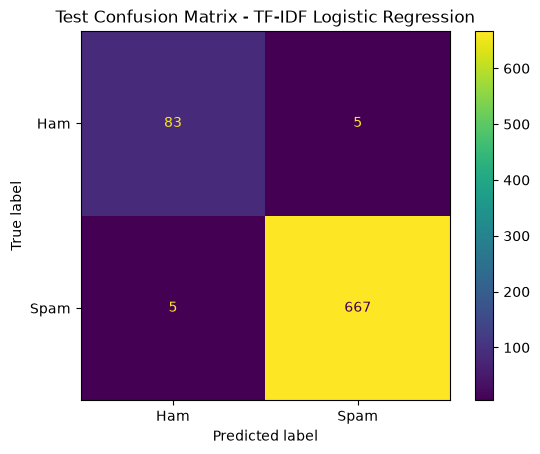

In [234]:
cm = confusion_matrix(
    y_test_array,
    y_test_pred_tfidf
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Ham", "Spam"]
)

disp.plot()
plt.title("Test Confusion Matrix - TF-IDF Logistic Regression")
plt.show()

In [235]:
experiment_results = []

experiment_results.append({
    "Embedding": "TF-IDF",
    "Model": "Logistic Regression",
    "Accuracy": tfidf_test_accuracy,
    "Precision": tfidf_test_precision,
    "Recall": tfidf_test_recall,
    "F1": tfidf_test_f1
})

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import pandas as pd

C_values = [0.001, 0.01, 0.1, 1, 10, 100, 500, 1000]

train_accuracies = []
val_accuracies = []

for C_value in C_values:
    model = LogisticRegression(
        C=C_value, #inverse regularization
        class_weight="balanced",
        max_iter=2000,
        random_state=42,
        solver="liblinear"
    )

    model.fit(X_train_tfidf, y_train_array)

    train_predictions = model.predict(X_train_tfidf)
    val_predictions = model.predict(X_val_tfidf)

    train_accuracy = accuracy_score(
        y_train_array,
        train_predictions
    )

    val_accuracy = accuracy_score(
        y_val_array,
        val_predictions
    )

    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)

RNN, GRU, and LSTM models require ordered token sequences because they process text one time step at a time. Standard TF-IDF produces one unordered document-level vector and does not preserve word order. Therefore, TF-IDF was used with Logistic Regression as the classical baseline, while Word2Vec and GloVe token embeddings were used as inputs to the recurrent neural-network architectures.

For an additional EXPERIMENTAL baseline, the TF-IDF document vectors were reshaped from two dimensions into three dimensions and treated as artificial sequences. Each TF-IDF feature was interpreted as one time step with an input size of one. This allowed the vectors to be processed by recurrent models. However, the resulting order represents TF-IDF vocabulary indices rather than the original word order, so the experiment does not provide a linguistically meaningful sequential representation.

In [239]:
X_train_rnn = torch.tensor(
    X_train_tfidf.toarray(),
    dtype=torch.float32
).unsqueeze(-1)

X_val_rnn = torch.tensor(
    X_val_tfidf.toarray(),
    dtype=torch.float32
).unsqueeze(-1)

X_test_rnn = torch.tensor(
    X_test_tfidf.toarray(),
    dtype=torch.float32
).unsqueeze(-1)

print("Training shape:", X_train_rnn.shape)
print("Validation shape:", X_val_rnn.shape)
print("Testing shape:", X_test_rnn.shape)

Training shape: torch.Size([1227, 2442, 1])
Validation shape: torch.Size([760, 2442, 1])
Testing shape: torch.Size([760, 2442, 1])


In [240]:
y_train_tensor = torch.tensor(
    y_train_array,
    dtype=torch.float32
)

y_val_tensor = torch.tensor(
    y_val_array,
    dtype=torch.float32
)

y_test_tensor = torch.tensor(
    y_test_array,
    dtype=torch.float32
)

In [241]:
from torch.utils.data import TensorDataset, DataLoader

BATCH_SIZE = 64

train_dataset_tfidf_rnn = TensorDataset(
    X_train_rnn,
    y_train_tensor
)

val_dataset_tfidf_rnn = TensorDataset(
    X_val_rnn,
    y_val_tensor
)

test_dataset_tfidf_rnn = TensorDataset(
    X_test_rnn,
    y_test_tensor
)

train_loader_tfidf_rnn = DataLoader(
    train_dataset_tfidf_rnn,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader_tfidf_rnn = DataLoader(
    val_dataset_tfidf_rnn,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader_tfidf_rnn = DataLoader(
    test_dataset_tfidf_rnn,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [242]:
import torch.nn as nn

class TfidfRNN(nn.Module):
    def __init__(
        self,
        hidden_size=64,
        num_layers=1,
        dropout=0.0
    ):
        super().__init__()

        self.rnn = nn.RNN(
            input_size=1,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        _, hidden = self.rnn(x)

        final_hidden = hidden[-1]
        final_hidden = self.dropout(final_hidden)

        logits = self.fc(final_hidden).squeeze(1)

        return logits

In [243]:
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

tfidf_rnn_model = TfidfRNN(
    hidden_size=64,
    num_layers=1,
    dropout=0.2
).to(DEVICE)

print(tfidf_rnn_model)

TfidfRNN(
  (rnn): RNN(1, 64, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


In [244]:
import copy
import torch
import torch.nn as nn

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    tfidf_rnn_model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

EPOCHS = 20
PATIENCE = 4

best_val_loss = float("inf")
best_model_weights = None
epochs_without_improvement = 0

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(EPOCHS):

    # Training
    tfidf_rnn_model.train()

    total_train_loss = 0
    total_train_correct = 0
    total_train_samples = 0

    for X_batch, y_batch in train_loader_tfidf_rnn:

        X_batch = X_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)

        optimizer.zero_grad()

        outputs = tfidf_rnn_model(X_batch)

        loss = criterion(outputs, y_batch)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            tfidf_rnn_model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        probabilities = torch.sigmoid(outputs)
        predictions = (probabilities >= 0.5).float()

        total_train_loss += loss.item() * X_batch.size(0)

        total_train_correct += (
            predictions == y_batch
        ).sum().item()

        total_train_samples += X_batch.size(0)

    train_loss = total_train_loss / total_train_samples
    train_accuracy = total_train_correct / total_train_samples

    # Validation
    tfidf_rnn_model.eval()

    total_val_loss = 0
    total_val_correct = 0
    total_val_samples = 0

    with torch.no_grad():

        for X_batch, y_batch in val_loader_tfidf_rnn:

            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            outputs = tfidf_rnn_model(X_batch)

            loss = criterion(outputs, y_batch)

            probabilities = torch.sigmoid(outputs)
            predictions = (probabilities >= 0.5).float()

            total_val_loss += loss.item() * X_batch.size(0)

            total_val_correct += (
                predictions == y_batch
            ).sum().item()

            total_val_samples += X_batch.size(0)

    val_loss = total_val_loss / total_val_samples
    val_accuracy = total_val_correct / total_val_samples

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)

    print(
        f"Epoch {epoch + 1:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Acc: {val_accuracy:.4f}"
    )

    # Early stopping
    if val_loss < best_val_loss:

        best_val_loss = val_loss

        best_model_weights = copy.deepcopy(
            tfidf_rnn_model.state_dict()
        )

        epochs_without_improvement = 0

    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= PATIENCE:
        print(
            f"Early stopping triggered at epoch {epoch + 1}"
        )
        break

tfidf_rnn_model.load_state_dict(best_model_weights)

Epoch 01/20 | Train Loss: 0.6501 | Val Loss: 0.4845 | Train Acc: 0.6667 | Val Acc: 0.8855
Epoch 02/20 | Train Loss: 0.6399 | Val Loss: 0.4935 | Train Acc: 0.6667 | Val Acc: 0.8855
Epoch 03/20 | Train Loss: 0.6373 | Val Loss: 0.4821 | Train Acc: 0.6667 | Val Acc: 0.8855
Epoch 04/20 | Train Loss: 0.6388 | Val Loss: 0.5012 | Train Acc: 0.6667 | Val Acc: 0.8855
Epoch 05/20 | Train Loss: 0.6369 | Val Loss: 0.4906 | Train Acc: 0.6667 | Val Acc: 0.8855
Epoch 06/20 | Train Loss: 0.6385 | Val Loss: 0.4922 | Train Acc: 0.6667 | Val Acc: 0.8855
Epoch 07/20 | Train Loss: 0.6369 | Val Loss: 0.4878 | Train Acc: 0.6667 | Val Acc: 0.8855
Early stopping triggered at epoch 7


<All keys matched successfully>

In [245]:
tfidf_rnn_model.eval()

test_probabilities = []
test_predictions = []
test_true_labels = []

with torch.no_grad():

    for X_batch, y_batch in test_loader_tfidf_rnn:

        X_batch = X_batch.to(DEVICE)

        outputs = tfidf_rnn_model(X_batch)

        probabilities = torch.sigmoid(outputs)

        predictions = (
            probabilities >= 0.5
        ).int()

        test_probabilities.extend(
            probabilities.cpu().numpy()
        )

        test_predictions.extend(
            predictions.cpu().numpy()
        )

        test_true_labels.extend(
            y_batch.numpy()
        )

In [246]:
import numpy as np

y_test_true_tfidf_rnn = np.array(
    test_true_labels
).astype(int)

y_test_pred_tfidf_rnn = np.array(
    test_predictions
).astype(int)

y_test_prob_tfidf_rnn = np.array(
    test_probabilities
)

In [247]:
from sklearn.metrics import classification_report

print("TF-IDF RNN Test Classification Report:")

print(
    classification_report(
        y_test_true_tfidf_rnn,
        y_test_pred_tfidf_rnn,
        target_names=["Ham", "Spam"],
        zero_division=0
    )
)

TF-IDF RNN Test Classification Report:
              precision    recall  f1-score   support

         Ham       0.00      0.00      0.00        88
        Spam       0.88      1.00      0.94       672

    accuracy                           0.88       760
   macro avg       0.44      0.50      0.47       760
weighted avg       0.78      0.88      0.83       760



In [248]:


tfidf_rnn_accuracy = accuracy_score(
    y_test_true_tfidf_rnn,
    y_test_pred_tfidf_rnn
)

tfidf_rnn_precision = precision_score(
    y_test_true_tfidf_rnn,
    y_test_pred_tfidf_rnn,
    zero_division=0
)

tfidf_rnn_recall = recall_score(
    y_test_true_tfidf_rnn,
    y_test_pred_tfidf_rnn,
    zero_division=0
)

tfidf_rnn_f1 = f1_score(
    y_test_true_tfidf_rnn,
    y_test_pred_tfidf_rnn,
    zero_division=0
)

print("Test Accuracy:", tfidf_rnn_accuracy)
print("Test Precision:", tfidf_rnn_precision)
print("Test Recall:", tfidf_rnn_recall)
print("Test F1-score:", tfidf_rnn_f1)

Test Accuracy: 0.8842105263157894
Test Precision: 0.8842105263157894
Test Recall: 1.0
Test F1-score: 0.9385474860335196


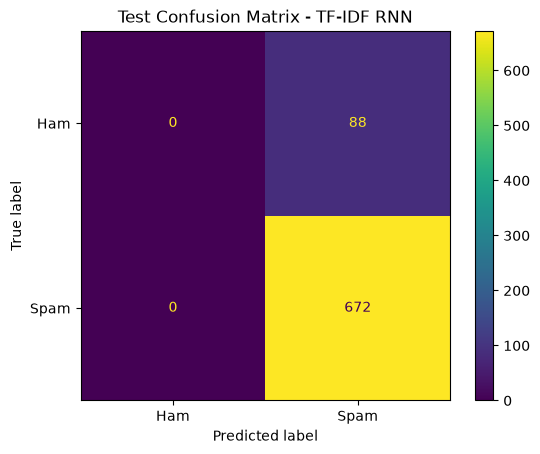

In [249]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay
)

cm = confusion_matrix(
    y_test_true_tfidf_rnn,
    y_test_pred_tfidf_rnn
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Ham", "Spam"]
)

disp.plot()

plt.title("Test Confusion Matrix - TF-IDF RNN")
plt.show()

### Limitation of Using TF-IDF with RNN, GRU, and LSTM

TF-IDF represents each complete message as a fixed vector of term importance values. It does not preserve the original order of words in the message.

To test TF-IDF with a recurrent neural network, the two-dimensional TF-IDF matrix was reshaped into a three-dimensional tensor.

This reshaping allows the data to match the input format expected by RNN, GRU, and LSTM models. However, it does not create a real linguistic sequence. Each artificial time step represents a TF-IDF vocabulary feature rather than a word appearing at a specific position in the original message.

As a result, the recurrent model processes TF-IDF feature columns as if they were ordered time steps, even though their order has no sequential meaning. The model cannot learn relationships between consecutive words or capture the original sentence structure.

The experiment showed that the TF-IDF RNN failed to distinguish correctly between ham and spam and collapsed into predicting only one class. Therefore, TF-IDF is a weak and conceptually inappropriate input representation for sequence models such as RNN, GRU, and LSTM.

TF-IDF remains effective with classical models such as Logistic Regression, while Word2Vec and GloVe are more suitable for recurrent neural networks because they preserve token-level sequence information.